To visualize Bias effectively, we compare a model that makes overly simplistic assumptions (**High Bias**) against one that is flexible enough to capture the true pattern (**Low Bias**).

In the code below, we use a simple linear model ($y=mx+b$) to represent High Bias. Because a straight line cannot "bend" to fit a curve, it consistently misses the target, regardless of how much data you give it.

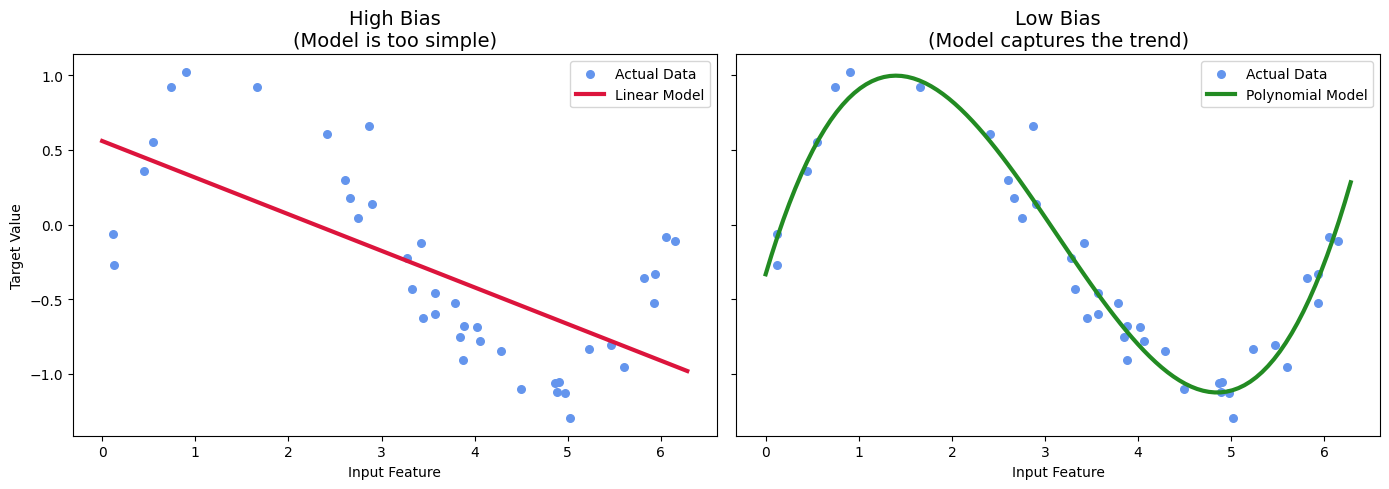

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Setup data: A simple sine wave with a bit of noise
np.random.seed(0)
X = np.sort(np.random.rand(40, 1) * 2 * np.pi, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])
x_plot = np.linspace(0, 2 * np.pi, 100).reshape(-1, 1)

# 2. Create Models
# High Bias: Simple Linear Regression (cannot capture the curve)
high_bias_model = LinearRegression().fit(X, y)

# Low Bias: Polynomial Regression (Degree 3 - flexible enough for a sine wave)
low_bias_model = make_pipeline(PolynomialFeatures(3), LinearRegression()).fit(X, y)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Graph 1: High Bias (Underfitting)
axes[0].scatter(X, y, color='cornflowerblue', s=30, label="Actual Data")
axes[0].plot(x_plot, high_bias_model.predict(x_plot), color='crimson', lw=3, label="Linear Model")
axes[0].set_title("High Bias\n(Model is too simple)", fontsize=14)
axes[0].set_xlabel("Input Feature")
axes[0].set_ylabel("Target Value")
axes[0].legend()

# Graph 2: Low Bias (Good Fit)
axes[1].scatter(X, y, color='cornflowerblue', s=30, label="Actual Data")
axes[1].plot(x_plot, low_bias_model.predict(x_plot), color='forestgreen', lw=3, label="Polynomial Model")
axes[1].set_title("Low Bias\n(Model captures the trend)", fontsize=14)
axes[1].set_xlabel("Input Feature")
axes[1].legend()

plt.tight_layout()
plt.show()

* **High Bias (Left Graph):** Notice how the red line completely ignores the "wave" shape of the data. It has a strong "prejudice" that the relationship is linear. This results in high error on both the training data and any new data.
* **Low Bias (Right Graph):** The green line is flexible. It accurately follows the curvature of the data. It has "learned" the signal rather than imposing a rigid structure on it.

### Defining the "Bias" Term
Mathematically, bias is defined as:
$$\text{Bias}[\hat{f}(x)] = E[\hat{f}(x)] - f(x)$$

Where:
* $E[\hat{f}(x)]$ is the average prediction of your model across different training sets.
* $f(x)$ is the true value you are trying to predict.